# HMM-Diffusion

Regime-conditional synthetic financial time series. Volatility regimes are detected on S&P 500 total
return log returns, one unconditional diffusion specialist is trained per regime, and an HMM
estimates the regime path used to stitch the specialists' output into a single series.

This reproduces the pipeline of `Supervised HMMs.ipynb` with the GAN replaced by diffusion. Four HMM
variants are fitted and compared: supervised, Markov switching, semi-supervised, and neural.

## Objective

The HMM is not the generator. It supplies a regime path, and each step of that path selects which
specialist's pool the next value is drawn from. Two things are therefore being measured at once: how
well the specialists reproduce their regime's return distribution, and how well the HMM recovers the
regime path from the emissions alone.

## Prerequisites

Run in order before this notebook:

```
python scripts/01_label_regimes.py
python scripts/02_build_diffusion_dataset.py
./scripts/03_train_specialists.sh      # requires a GPU
python scripts/04_generate_pools.py
```

Without step 3 and 4 the notebook falls back to placeholder pools resampled from the real returns, so
every cell still runs, but the generated-data results are meaningless. The fallback is reported
explicitly below.

## Deviations from the reference

Two changes were forced by library versions rather than chosen. Both are detailed in `README.md`:
the changepoint penalty had to be retuned because the original default no longer yields five
regimes, and the `Corr` loss term was dropped because it is undefined for univariate data.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))

from hmmdiff.config import bootstrap_imports, config_path, load_config

cfg = load_config()
bootstrap_imports()  # puts third_party/hmmgan and third_party/diffusion on sys.path

from hmmdiff import data, models, plots, pools, regimes, stitch

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

N_REGIMES = cfg["regimes"]["n_regimes"]
TOP_K = cfg["hmm"]["top_k"]
REFERENCE = cfg["reference"]

print(f"{N_REGIMES} regimes, seq_len {cfg['diffusion']['seq_len']}")

5 regimes, seq_len 128


## Data preparation

S&P 500 total return closing prices, converted to log returns and standardized by the mean and
standard deviation of the whole series. Standardizing globally rather than per split is what the
reference does; it leaks a small amount of scale information from test into train, which matters for
absolute return levels but not for the regime structure this pipeline studies.

The series is split 75/25 into train and test, and the train portion is split 75/25 again into an
inner training slice and a validation slice. Only the train portion is ever used below; the test
portion is held out and untouched.

returns        9031  1988-01-20 to 2022-08-31
train / test   6773 / 2258
inner / val    5079 / 1694


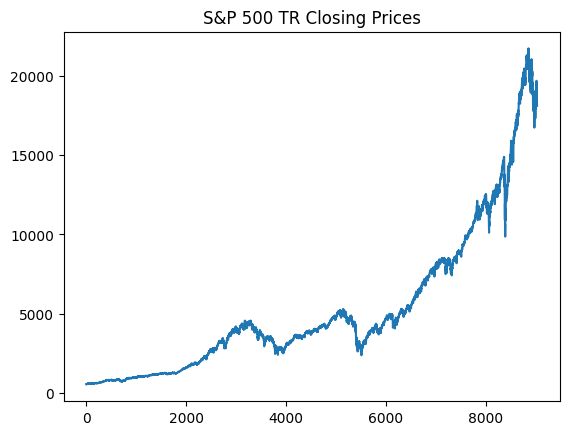

In [2]:
prices = data.load_prices(cfg)
returns = data.load_returns(cfg)
splits = data.compute_splits(len(returns), cfg)

train_series = data.train_returns(returns)

print(f"returns      {len(returns):>6}  {returns['date'].iloc[0]} to {returns['date'].iloc[-1]}")
print(f"train / test {splits.n_train:>6} / {splits.n_test}")
print(f"inner / val  {splits.n_train_inner:>6} / {splits.n_val}")

assert splits.n_train == REFERENCE["n_train"], "train split does not match the reference"
assert splits.n_train_inner == REFERENCE["n_train_inner"], "inner split does not match"

plots.plot_prices(prices.to_numpy(dtype=float))

## Volatility regimes

Labels are loaded from the cache written by `scripts/01_label_regimes.py` rather than recomputed
here. This is deliberate. The clustering step is not deterministic across environments, so recomputing
would risk the notebook and the trained specialists disagreeing about what each regime means. The
cache is the single source of truth for every stage.

The labeling chain is: GARCH(1,1) conditional volatility, PELT changepoint detection, a Wasserstein
affinity between segments, then self-tuning spectral clustering. Labels are finally reordered so that
regime index increases with variance, which is what makes "regime 4 is the crisis regime" true by
construction rather than by luck.

,n_days,mean,variance
regime,,,
0,1085,0.0116,0.2419
1,2818,0.0183,0.4526
2,1245,0.0385,0.9021
3,1370,-0.0538,1.6940
4,255,-0.1706,7.0621


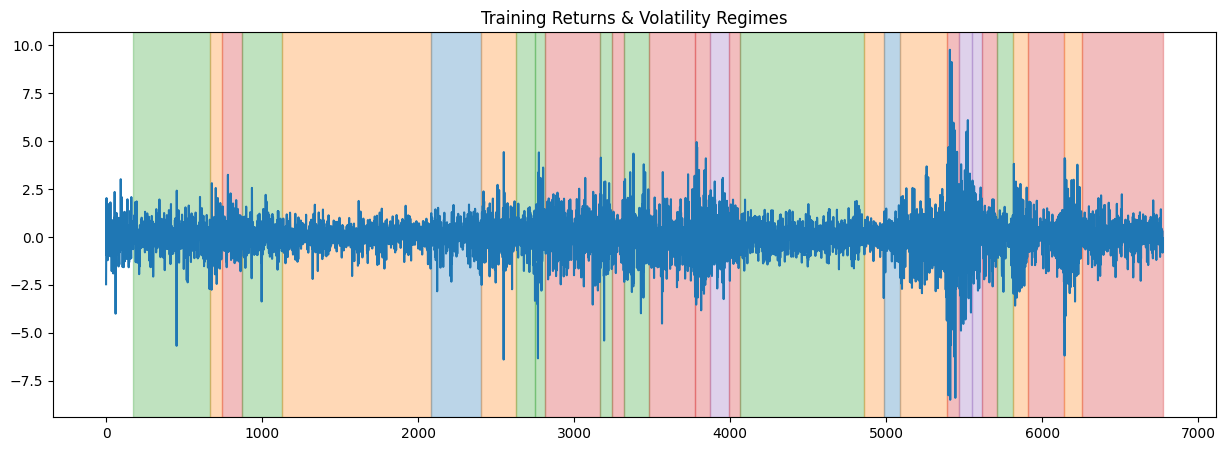

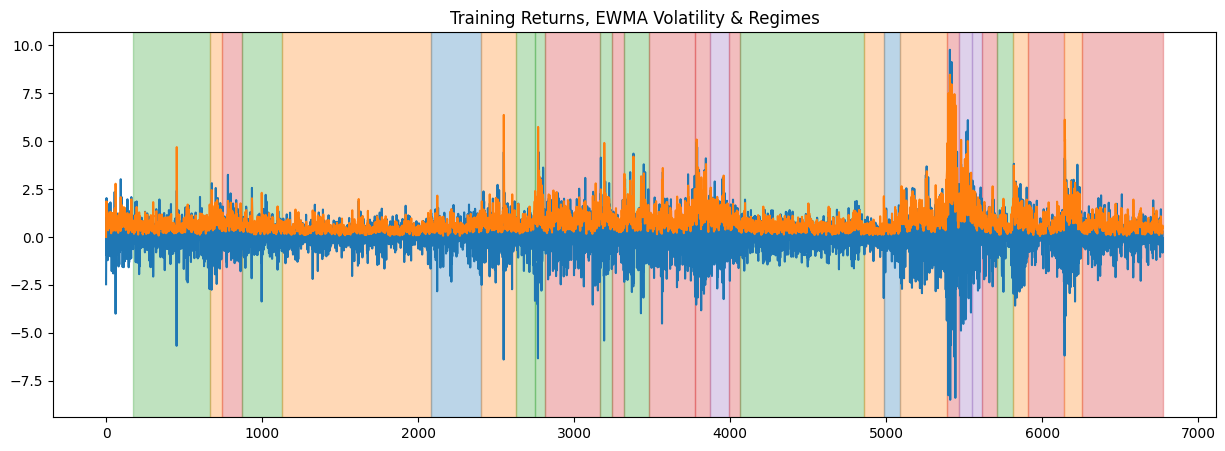

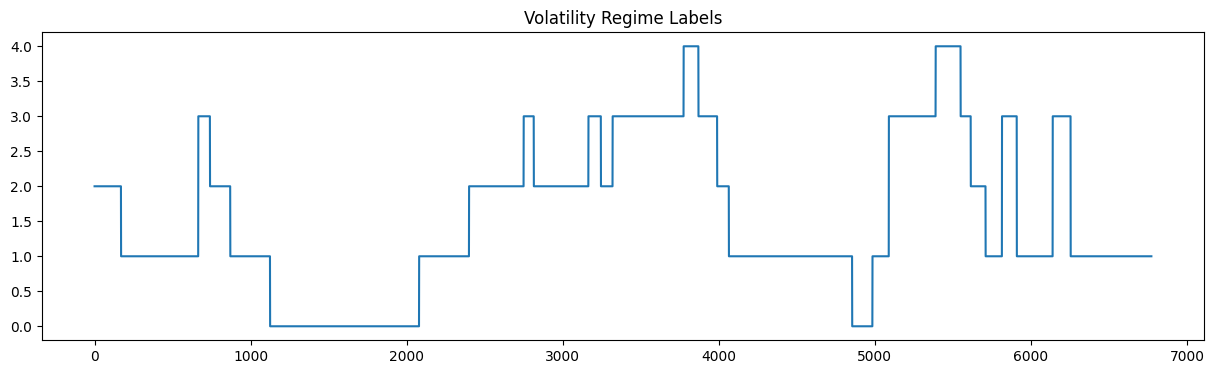

In [3]:
labels = regimes.load_labels(config_path(cfg, "regime_labels"))
regime_labels = labels.labels.astype(int)
segment_colors = labels.segment_colors()

display(plots.regime_moments(train_series, regime_labels, N_REGIMES))

plots.plot_regime_spans(
    train_series,
    labels.changepoints,
    segment_colors,
    title="Training Returns & Volatility Regimes",
)
plots.plot_regime_spans(
    train_series,
    labels.changepoints,
    segment_colors,
    overlay=regimes.ewm_volatility(train_series, cfg["regimes"]["ewm_com"]),
    title="Training Returns, EWMA Volatility & Regimes",
)
plots.plot_regime_labels(regime_labels)

## Model frames and transition structure

`train_data` and `val_data` hold the regime label, the emission, and the lagged emission that the
Markov switching variant needs. The split between them is temporal, not random, so the validation
slice is genuinely out of sample in time.

Because volatility regimes cluster in time, a temporal split does not distribute regimes evenly. The
check below reports the per-regime counts in each slice. Every regime must appear in the training
slice or the HMM has no data from which to estimate that regime's emission parameters, and its values
would be drawn from the prior instead.

The empirical transition matrix is dominated by its diagonal, since regimes persist for months. The
outbound matrix zeroes the diagonal and renormalizes, which is the more informative view of where the
market goes when a regime actually ends.

In [4]:
train_data, val_data = data.build_model_frames(returns, regime_labels, cfg)

# The reference recomputes validation labels by slicing the cached label array; keep that explicit.
val_regimes = regime_labels[splits.train_val_split : splits.train_val_split + len(val_data)]

coverage = pd.DataFrame(
    {
        "train": np.bincount(train_data.regime.values, minlength=N_REGIMES),
        "val": np.bincount(val_regimes, minlength=N_REGIMES),
    },
    index=pd.Index(range(N_REGIMES), name="regime"),
)
display(coverage)

missing_train = coverage.index[coverage["train"] == 0].tolist()
assert not missing_train, (
    f"Regimes {missing_train} are absent from the training slice, so their emission parameters "
    "would come from the prior. Re-run scripts/01_label_regimes.py with a different "
    "regimes.changepoint_penalty."
)
missing_val = coverage.index[coverage["val"] == 0].tolist()
if missing_val:
    print(
        f"Note: regimes {missing_val} do not occur in the validation slice, so validation accuracy "
        "is measured over the remaining regimes only."
    )

,train,val
regime,,
0,1085,0
1,1954,864
2,1150,95
3,795,575
4,95,160


Note: regimes [0] do not occur in the validation slice, so validation accuracy is measured over the remaining regimes only.


In [5]:
empirical_transmat = regimes.empirical_transition_matrix(regime_labels, N_REGIMES)
outbound_transmat = regimes.outbound_transition_matrix(empirical_transmat, N_REGIMES)

index = pd.Index(range(N_REGIMES), name="from")
columns = pd.Index(range(N_REGIMES), name="to")

print("Empirical transition matrix")
display(pd.DataFrame(empirical_transmat, index=index, columns=columns))

print("Outbound transition matrix (diagonal removed, rows renormalized)")
display(pd.DataFrame(outbound_transmat, index=index, columns=columns))

print("Average consecutive days per visit")
display(pd.Series(regimes.average_regime_length(regime_labels)).sort_index())

Empirical transition matrix


to,0,1,2,3,4
from,,,,,
0,0.9982,0.0018,0.0000,0.0000,0.0000
1,0.0007,0.9975,0.0004,0.0014,0.0000
2,0.0000,0.0032,0.9944,0.0024,0.0000
3,0.0000,0.0015,0.0036,0.9934,0.0015
4,0.0000,0.0000,0.0000,0.0078,0.9922


Outbound transition matrix (diagonal removed, rows renormalized)


to,0,1,2,3,4
from,,,,,
0,0.0000,1.0000,0.0000,0.0000,0.0000
1,0.2857,0.0000,0.1429,0.5714,0.0000
2,0.0000,0.5714,0.0000,0.4286,0.0000
3,0.0000,0.2222,0.5556,0.0000,0.2222
4,0.0000,0.0000,0.0000,1.0000,0.0000


Average consecutive days per visit


0   542.5000
1   352.2500
2   177.8571
3   152.2222
4   127.5000
dtype: float64

## Diffusion pools

One pool of synthetic 128-day windows per regime, produced by that regime's specialist. The pools are
already in the same units as `emission`, z-scored log returns, because the specialists were trained on
z-scored windows and the dataset's quantile transform is inverted on generation.

Each pool is flattened into a single sequence. Stitching then walks a regime path and takes the next
unused value from the relevant pool. Concatenating independent windows introduces a discontinuity
every 128 steps; the reference GAN has the identical artifact, since it also concatenates independent
chunks, so this is a shared limitation rather than a regression.

If the specialists have not been trained yet, placeholder pools resampled from the real per-regime
returns are substituted so the rest of the notebook stays runnable. Results computed from placeholders
describe the resampler, not the diffusion models.

In [6]:
pools_root = config_path(cfg, "pools")
USING_PLACEHOLDER = not pools.pools_available(pools_root, N_REGIMES)
GENERATED_TITLE = (
    "PLACEHOLDER: Resampled Real Returns (not diffusion)"
    if USING_PLACEHOLDER
    else "HMM Diffusion Generated Returns"
)

if USING_PLACEHOLDER:
    print(
        "WARNING: no trained specialist pools found under "
        f"{pools_root.relative_to(REPO_ROOT)}.\n"
        "Falling back to placeholder pools resampled from the real per-regime returns.\n"
        "Run scripts/03_train_specialists.sh and scripts/04_generate_pools.py for real results."
    )
    generated_images = pools.placeholder_pools(
        train_series, regime_labels, N_REGIMES, size=len(train_series), seed=0
    )
else:
    generated_images = pools.load_generated_images(pools_root, N_REGIMES)
    for k in range(N_REGIMES):
        meta = pools.load_pool_meta(pools_root, k)
        print(f"regime {k}: {meta.get('n_pool')} windows from {Path(meta.get('checkpoint_dir', '')).name}")

pool_summary = pd.DataFrame(
    {
        "pool_length": [generated_images[str(k)].size for k in range(N_REGIMES)],
        "pool_mean": [generated_images[str(k)].mean() for k in range(N_REGIMES)],
        "pool_var": [generated_images[str(k)].var() for k in range(N_REGIMES)],
        "real_mean": [train_series[regime_labels == k].mean() for k in range(N_REGIMES)],
        "real_var": [train_series[regime_labels == k].var() for k in range(N_REGIMES)],
    },
    index=pd.Index(range(N_REGIMES), name="regime"),
)
display(pool_summary)

# Every regime path that will be stitched below, so pool sufficiency is checked up front rather
# than failing partway through a variant.
candidate_paths = [train_data.regime.values, val_regimes]
problems, _ = pools.check_pools(
    generated_images, candidate_paths, train_series, regime_labels, N_REGIMES
)
for problem in problems:
    print(f"POOL CHECK: {problem}")
if not problems:
    print("Pool checks passed: finite, sufficient for every regime path, variance ordering matches.")

Falling back to placeholder pools resampled from the real per-regime returns.
Run scripts/03_train_specialists.sh and scripts/04_generate_pools.py for real results.


,pool_length,pool_mean,pool_var,real_mean,real_var
regime,,,,,
0,6773,0.0068,0.2519,0.0116,0.2419
1,6773,0.0204,0.4507,0.0183,0.4526
2,6773,0.0383,0.8983,0.0385,0.9021
3,6773,-0.0355,1.6163,-0.0538,1.6940
4,6773,-0.1572,7.2240,-0.1706,7.0621


Pool checks passed: finite, sufficient for every regime path, variance ordering matches.


## HMM variants

Four ways of estimating the same three quantities: a transition matrix and per-regime Gaussian
emission parameters.

- **Supervised.** Regimes and emissions are both observed. NUTS.
- **Markov switching.** As above, with the emission mean regressed on the previous emission, so it can
  express short-term momentum or reversal within a regime.
- **Semi-supervised.** The first half of the training slice keeps its labels; the second half is
  unlabeled and contributes through a forward-algorithm factor.
- **Neural.** Emission parameters come from a small network rather than free parameters, fitted by SVI
  under a delta guide, so its estimates are MAP point estimates rather than posterior means.

All four are then evaluated identically: run forward-backward to get smoothed state posteriors,
compare the argmax against the true labels, stitch a synthetic series along the estimated path, and
tabulate per-regime moments.

Top-2 accuracy is reported alongside top-1 because adjacent volatility regimes overlap heavily by
construction; confusing regime 1 with regime 2 is a much smaller error than confusing regime 1 with
regime 4, and top-1 accuracy alone does not show that distinction.

In [7]:
init_dist = models.initial_distribution(train_data, N_REGIMES)


def evaluate_variant(key, fit):
    """Fit diagnostics, state estimation, stitching, and plots for one HMM variant."""
    print("=" * 78)
    print(fit.name)
    print("=" * 78)

    print("Posterior transition matrix")
    display(pd.DataFrame(fit.transmat.round(3), index=index, columns=columns))
    print("Emission parameters")
    display(fit.summary())

    train_probs, train_est = models.estimate_states(
        fit, train_data.emission.values, init_dist, N_REGIMES
    )
    val_probs, val_est = models.estimate_states(
        fit, val_data.emission.values, init_dist, N_REGIMES
    )
    train_acc = models.accuracy_report(
        train_data.regime.values, train_est, train_probs, N_REGIMES, TOP_K
    )
    val_acc = models.accuracy_report(val_regimes, val_est, val_probs, N_REGIMES, TOP_K)

    ref = REFERENCE["accuracy"][key]
    print(
        f"Train accuracy {train_acc['accuracy']:>7.2%} (reference {ref['train']:.2%})   "
        f"top-{TOP_K} {train_acc[f'top_{TOP_K}_accuracy']:>7.2%} (reference {ref['train_top2']:.2%})"
    )
    print(
        f"Val   accuracy {val_acc['accuracy']:>7.2%} (reference {ref['val']:.2%})   "
        f"top-{TOP_K} {val_acc[f'top_{TOP_K}_accuracy']:>7.2%} (reference {ref['val_top2']:.2%})"
    )

    plots.plot_estimates(train_est, train_data.regime.values, f"{fit.name}: Train")
    plots.plot_estimates(val_est, val_regimes, f"{fit.name}: Validation")

    # Oracle stitch uses the true labels; the HMM stitch uses the estimated path. Comparing them
    # separates generator quality from state-estimation error.
    oracle = stitch.stitch(generated_images, train_data.regime.values)
    estimated = stitch.stitch(generated_images, train_est)

    plots.plot_real_vs_generated(
        train_data.emission.values,
        train_data.regime.values,
        estimated,
        train_est,
        generated_title=GENERATED_TITLE,
    )

    table = stitch.backtest_table(
        train_data.emission.values,
        train_data.regime.values,
        estimated,
        train_est,
        N_REGIMES,
    )
    display(table)

    return {
        "name": fit.name,
        "fit": fit,
        "train_accuracy": train_acc["accuracy"],
        "train_top_k": train_acc[f"top_{TOP_K}_accuracy"],
        "val_accuracy": val_acc["accuracy"],
        "val_top_k": val_acc[f"top_{TOP_K}_accuracy"],
        "oracle": oracle,
        "estimated": estimated,
        "backtest": table,
    }


results = {}

sample: 100%|██████████| 300/300 [00:17<00:00, 17.06it/s, 15 steps of size 1.86e-01. acc. prob=0.77] 


Supervised HMM
Posterior transition matrix


to,0,1,2,3,4
from,,,,,
0,0.9970,0.0020,0.0010,0.0000,0.0000
1,0.0010,0.9980,0.0010,0.0010,0.0000
2,0.0000,0.0030,0.9940,0.0030,0.0000
3,0.0000,0.0000,0.0050,0.9930,0.0020
4,0.0020,0.0020,0.0020,0.0110,0.9830


Emission parameters


,mean,sigma
regime,,
0,0.0113,0.4935
1,0.0152,0.6605
2,0.0384,0.9532
3,-0.0631,1.2639
4,-0.0840,1.9195


100%|██████████| 5079/5079 [00:00<00:00, 44866.28it/s]
5079it [00:00, 77414.03it/s]
100%|██████████| 1694/1694 [00:00<00:00, 86190.95it/s]
1694it [00:00, 86672.49it/s]


Train accuracy  80.96% (reference 82.28%)   top-2  98.80% (reference 98.90%)
Val   accuracy  72.73% (reference 68.48%)   top-2  96.22% (reference 95.87%)


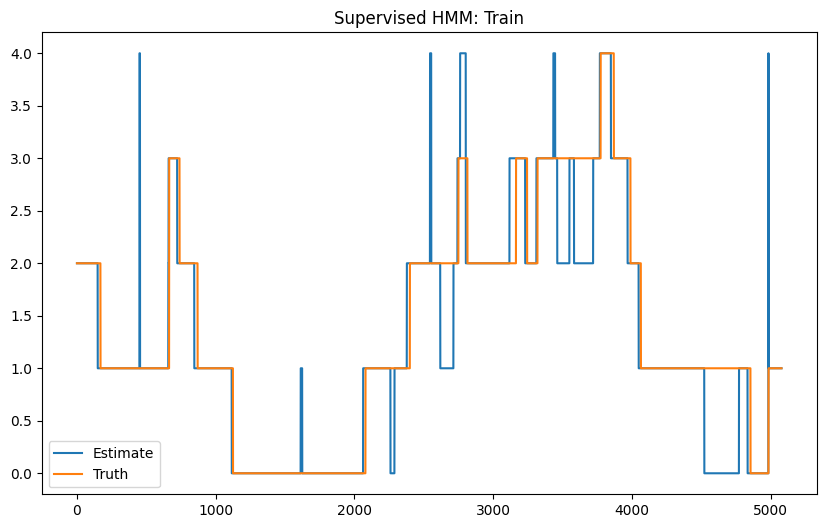

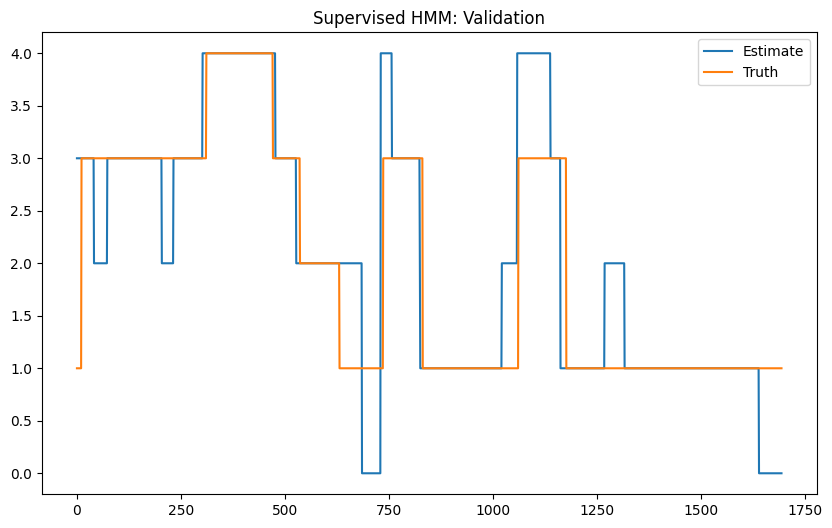

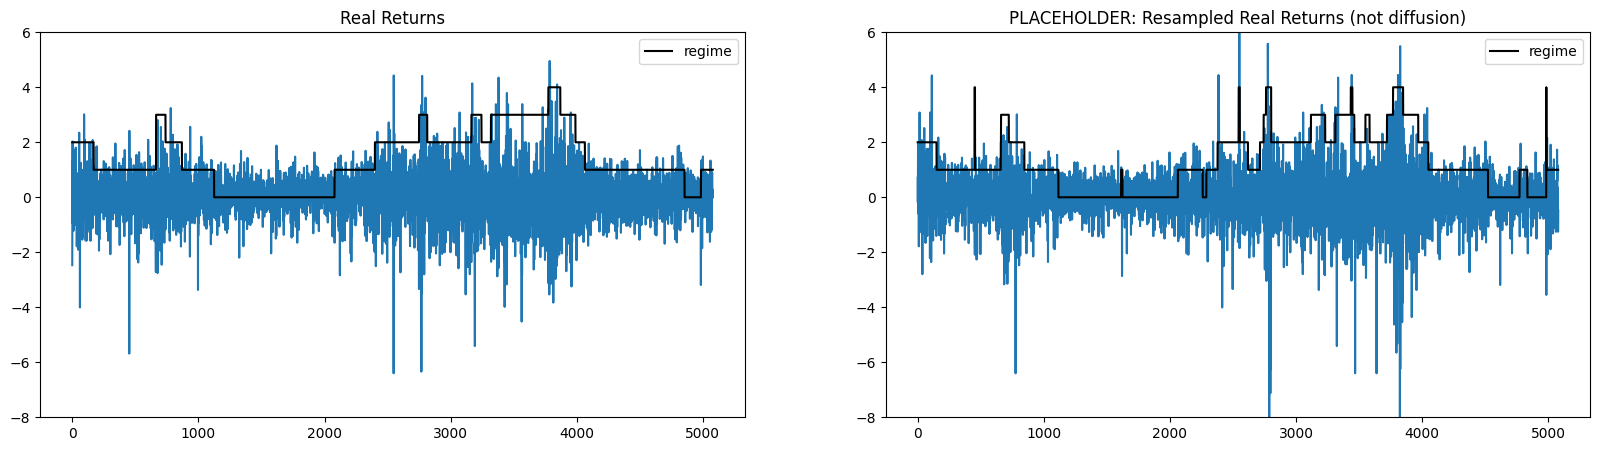

,n,real_mean,gen_mean,real_var,gen_var
regime,,,,,
0,1085,0.0116,0.0069,0.2421,0.2457
1,1954,0.0149,0.0204,0.4372,0.4344
2,1150,0.0355,0.0481,0.9049,0.9611
3,795,-0.0619,-0.1113,1.5925,1.7418
4,95,-0.0860,-0.1279,3.6447,5.5056


In [8]:
results["supervised"] = evaluate_variant(
    "supervised", models.fit_supervised_hmm(train_data, N_REGIMES, cfg)
)

sample: 100%|██████████| 300/300 [00:17<00:00, 16.69it/s, 15 steps of size 2.00e-01. acc. prob=0.87] 

Markov Switching Model
Posterior transition matrix


to,0,1,2,3,4
from,,,,,
0,0.9960,0.0020,0.0010,0.0000,0.0000
1,0.0010,0.9970,0.0010,0.0010,0.0000
2,0.0000,0.0030,0.9940,0.0030,0.0000
3,0.0000,0.0000,0.0050,0.9930,0.0010
4,0.0030,0.0030,0.0010,0.0140,0.9790


Emission parameters


,mean,sigma
regime,,
0,0.0118,0.4938
1,0.0146,0.6631
2,0.0374,0.9514
3,-0.0605,1.2651
4,-0.0713,1.9205


100%|██████████| 5079/5079 [00:00<00:00, 63799.39it/s]
5079it [00:00, 76150.49it/s]
100%|██████████| 1694/1694 [00:00<00:00, 82800.00it/s]
1694it [00:00, 79404.02it/s]


Train accuracy  80.25% (reference 82.00%)   top-2  98.64% (reference 98.92%)
Val   accuracy  74.97% (reference 68.60%)   top-2  96.16% (reference 95.22%)


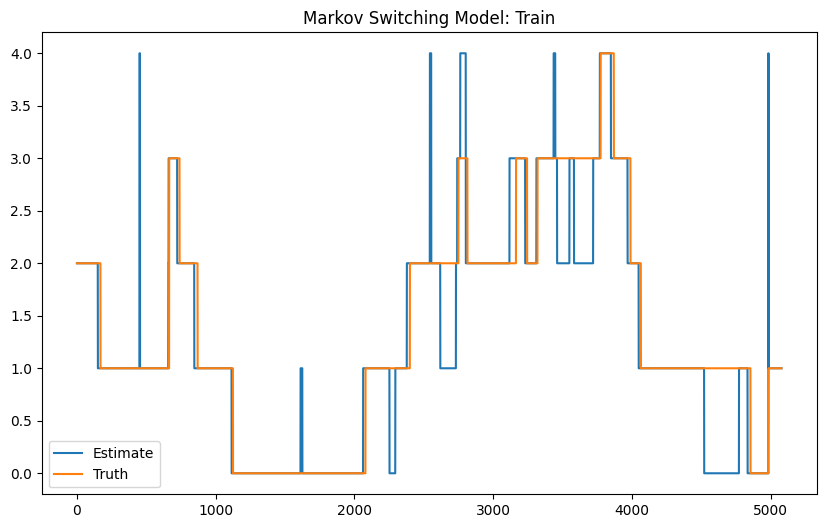

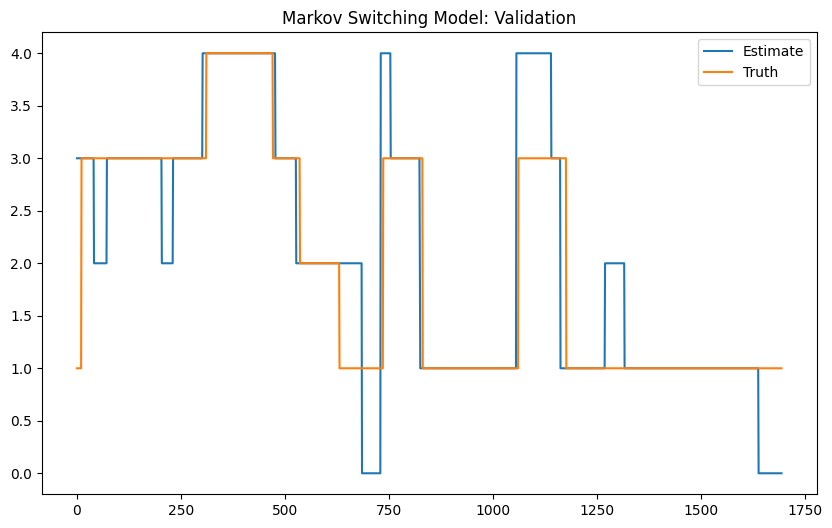

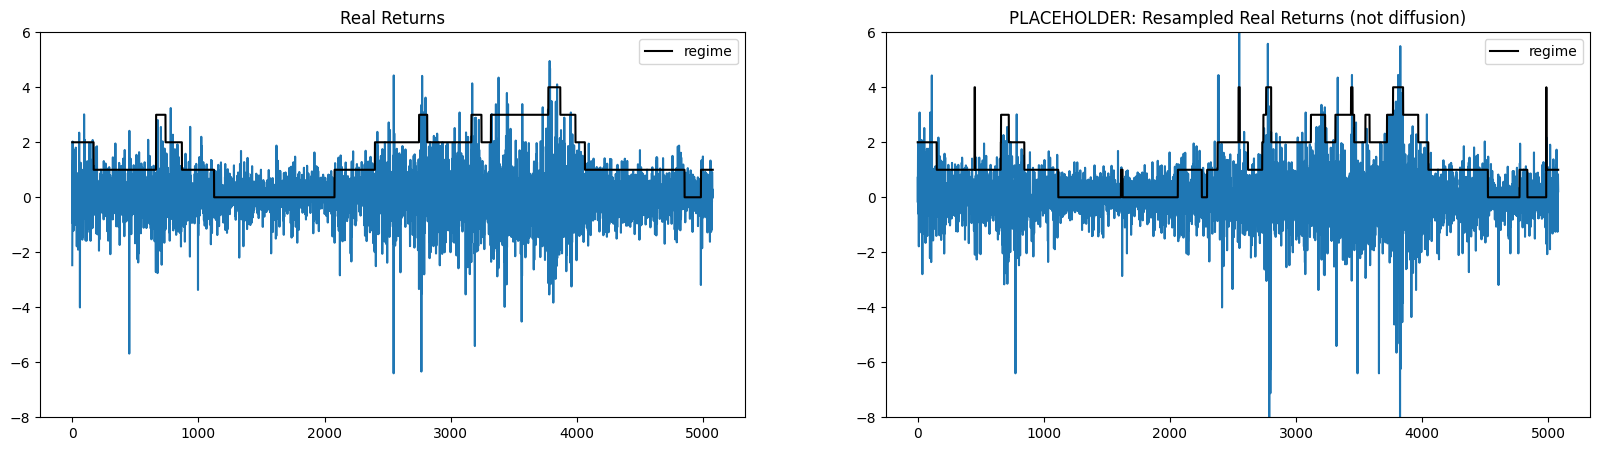

,n,real_mean,gen_mean,real_var,gen_var
regime,,,,,
0,1085,0.0116,0.0057,0.2421,0.2359
1,1954,0.0149,0.0251,0.4372,0.4339
2,1150,0.0355,0.0294,0.9049,0.9367
3,795,-0.0619,-0.0955,1.5925,1.7696
4,95,-0.0860,-0.1428,3.6447,5.4259


In [9]:
results["markov_switching"] = evaluate_variant(
    "markov_switching", models.fit_markov_switching(train_data, N_REGIMES, cfg)
)

[ -0.8692968 -37.921055  -38.303455   -1.901582   -2.6670055]
(2539,)
prev
JitTracer(float32[5])
cur
JitTracer(float32[])
trans
[[-2.603052  -1.7607605 -2.4121323 -2.3816977 -0.5585793]
 [-1.3753742 -0.9098027 -2.8357787 -1.4681387 -2.8891284]
 [-1.9357654 -0.687541  -3.4661908 -3.1763897 -1.2733107]
 [-0.4881314 -1.81827   -2.438177  -2.2725506 -3.394642 ]
 [-2.8772955 -2.5834103 -2.6981206 -0.8134196 -1.0285479]]
loc
[-0.27706242 -1.3087606   1.4700975  -1.1474452   0.5143523 ]
(5,)
[0.28611243 0.16749428 0.1470359  0.8830496  5.7329273 ]
(5,)
(5, 5)
[ -0.8692968 -37.921055  -38.303455   -1.901582   -2.6670055]
log_prob
GradTracer(primal=[ -0.8692968 -37.921055  -38.303455   -1.901582   -2.6670055], typeof(tangent)=f32[5])
(2539,)
prev
JitTracer(float32[5])
cur
JitTracer(float32[])
trans
GradTracer(primal=[[-2.603052  -1.7607605 -2.4121323 -2.3816977 -0.5585793]
 [-1.3753742 -0.9098027 -2.8357787 -1.4681387 -2.8891287]
 [-1.9357654 -0.687541  -3.4661908 -3.1763897 -1.2733107]
 [-0.48

  0%|          | 0/300 [00:00<?, ?it/s]

GradTracer(primal=JitTracer(float32[5]), typeof(tangent)=f32[5])
(2539,)
prev
JitTracer(float32[5])
cur
JitTracer(float32[])
trans
GradTracer(primal=JitTracer(float32[5,5]), typeof(tangent)=f32[5,5])
loc
GradTracer(primal=JitTracer(float32[5]), typeof(tangent)=f32[5])
(5,)
GradTracer(primal=JitTracer(float32[5]), typeof(tangent)=f32[5])
(5,)
(5, 5)
GradTracer(primal=JitTracer(float32[5]), typeof(tangent)=f32[5])
log_prob


sample: 100%|██████████| 300/300 [00:37<00:00,  8.10it/s, 113 steps of size 3.74e-02. acc. prob=0.91]

Semi-Supervised HMM
Posterior transition matrix


to,0,1,2,3,4
from,,,,,
0,0.9970,0.0020,0.0000,0.0010,0.0010
1,0.0030,0.9940,0.0010,0.0010,0.0020
2,0.0000,0.0050,0.9900,0.0010,0.0030
3,0.0010,0.0010,0.0120,0.9600,0.0260
4,0.0070,0.0040,0.0170,0.1080,0.8640


Emission parameters


,mean,sigma
regime,,
0,0.0134,0.4931
1,0.0249,0.6918
2,0.0345,0.9252
3,-0.1070,1.2224
4,-0.0740,2.2543


100%|██████████| 5079/5079 [00:00<00:00, 73632.35it/s]
5079it [00:00, 73606.65it/s]
100%|██████████| 1694/1694 [00:00<00:00, 70299.31it/s]
1694it [00:00, 68014.66it/s]


Train accuracy  73.38% (reference 77.65%)   top-2  97.07% (reference 98.07%)
Val   accuracy  68.95% (reference 68.48%)   top-2  96.04% (reference 95.75%)


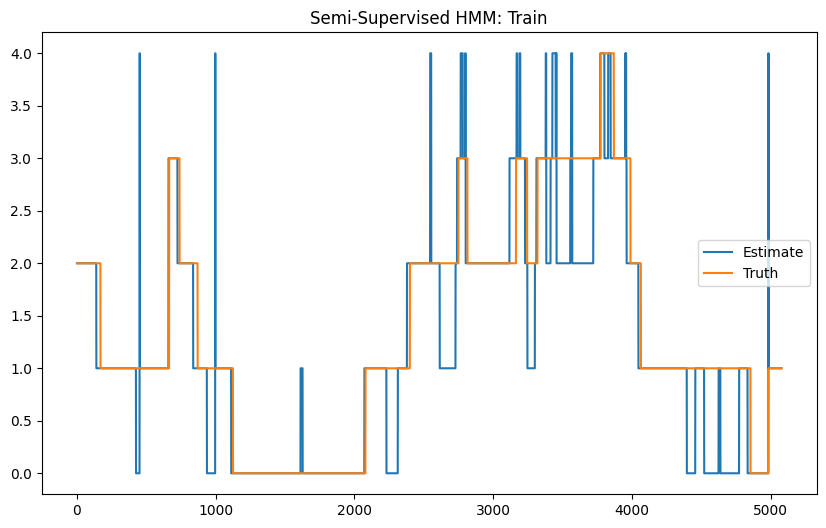

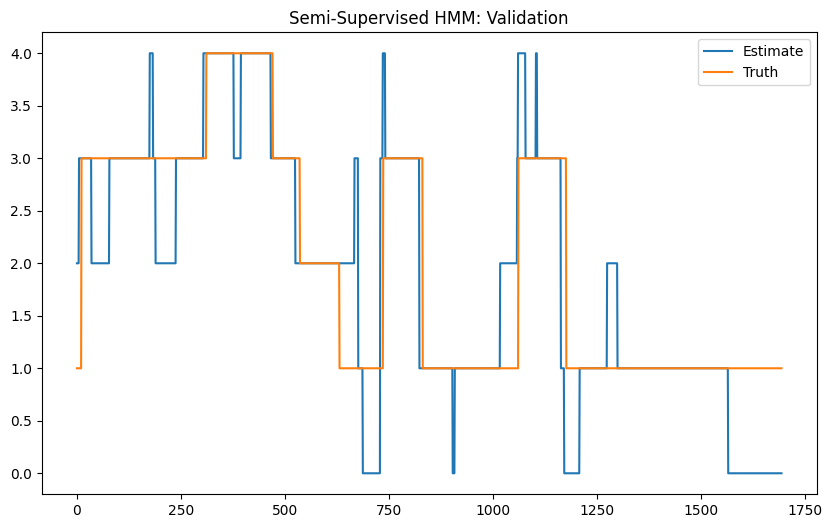

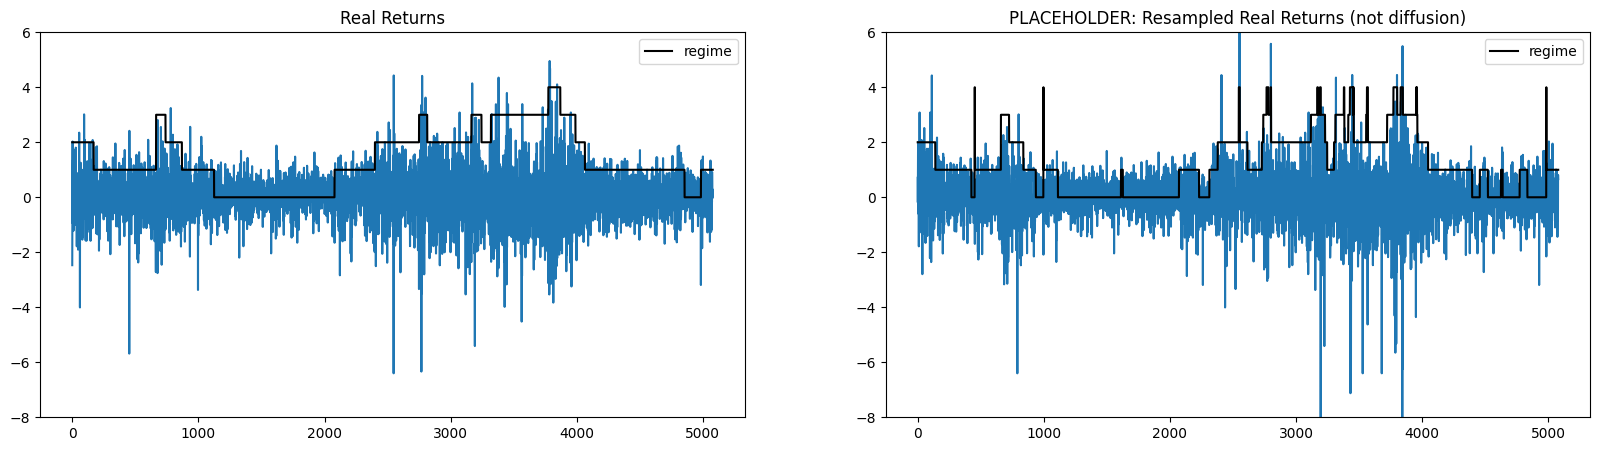

,n,real_mean,gen_mean,real_var,gen_var
regime,,,,,
0,1085,0.0116,0.0276,0.2421,0.2423
1,1954,0.0149,0.0085,0.4372,0.4045
2,1150,0.0355,0.0519,0.9049,0.9666
3,795,-0.0619,-0.0963,1.5925,1.6464
4,95,-0.0860,-0.0191,3.6447,4.9268


In [10]:
results["semi_supervised"] = evaluate_variant(
    "semi_supervised", models.fit_semi_supervised_hmm(train_data, N_REGIMES, cfg)
)

In [ ]:
neural_fit = models.fit_neural_hmm(train_data, N_REGIMES, cfg)
plots.plot_elbo(neural_fit.diagnostics["elbo_losses"])
results["neural"] = evaluate_variant("neural", neural_fit)

## Results

State-estimation accuracy for all four variants against the reference figures, then the per-regime
distributional fit of the generated series.

The moment comparison is grouped by the *true* regime while the generated values were drawn along the
*estimated* path, so a gap reflects both generator error and state-estimation error. The oracle
column isolates the generator by stitching along the true path instead.

In [ ]:
summary = pd.DataFrame(
    [
        {
            "variant": r["name"],
            "train": r["train_accuracy"],
            "train_ref": REFERENCE["accuracy"][key]["train"],
            f"train_top{TOP_K}": r["train_top_k"],
            f"train_top{TOP_K}_ref": REFERENCE["accuracy"][key]["train_top2"],
            "val": r["val_accuracy"],
            "val_ref": REFERENCE["accuracy"][key]["val"],
            f"val_top{TOP_K}": r["val_top_k"],
            f"val_top{TOP_K}_ref": REFERENCE["accuracy"][key]["val_top2"],
        }
        for key, r in results.items()
    ]
).set_index("variant")

display(summary.style.format("{:.2%}"))

In [ ]:
best_key = summary["val"].idxmax()
best = next(r for r in results.values() if r["name"] == best_key)

oracle_table = stitch.backtest_table(
    train_data.emission.values,
    train_data.regime.values,
    best["oracle"],
    train_data.regime.values,
    N_REGIMES,
)

comparison = pd.DataFrame(
    {
        "real_var": oracle_table["real_var"],
        "oracle_var": oracle_table["gen_var"],
        "hmm_var": best["backtest"]["gen_var"],
        "real_mean": oracle_table["real_mean"],
        "oracle_mean": oracle_table["gen_mean"],
        "hmm_mean": best["backtest"]["gen_mean"],
    }
)

print(f"Per-regime moments, stitched with {best_key}")
display(comparison)

if USING_PLACEHOLDER:
    print(
        "\nThese generated columns come from placeholder resampling, not the diffusion specialists."
    )

## Limitations

**Regime 4 is thin.** The highest-volatility regime covers roughly 255 of 6773 training days across
two segments, which is about one independent 128-day window. Its specialist has very little to learn
from and will largely reproduce its training data. This is a property of the data, not of the method:
crises are rare. Any claim about the crisis regime should be treated as unsupported.

**Labels are not reproducible bit-for-bit.** The cluster-count selection in the reference
implementation minimizes an un-normalized alignment cost with conjugate gradient, and its outcome
shifts with library versions. The changepoint penalty was retuned so that the pipeline yields five
variance-ordered regimes with all five present in the training slice. See `README.md`.

**Regime coverage is uneven across the split.** Because regimes persist for months, a temporal split
cannot distribute them evenly, and at least one regime is typically absent from the validation slice.
Validation accuracy is therefore measured over fewer than five regimes.

**Windows are stitched independently.** Concatenation introduces a discontinuity every 128 steps, and
nothing enforces continuity across a regime change. The generated series matches per-regime marginal
distributions far better than it matches the transition dynamics at boundaries.

**Global standardization leaks scale.** Log returns are z-scored using statistics of the entire
series, including the held-out portion, following the reference.

**Labels are exogenous.** The HMM is fitted against labels produced by a separate volatility-clustering
pipeline, so its accuracy measures agreement with that pipeline, not recovery of a ground-truth
latent state.